# PCA on genus level data

Import libraries

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import math
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

Read data

In [102]:
data = pd.read_csv('../datasets/latinbiota_merge_metaphlan_data.csv', sep = '\t', skiprows=1, index_col = 0)
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

Keep only genus level data

In [103]:
data_sp = data[data.index.astype(str).str.contains("g__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("t__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("s__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("unclass")]

Rename indexes getting using only genus name

In [104]:
new = []

for item in data_sp.index:
    new.append(item.split('|g__')[1].replace('|t__', ' ').replace('_', ' '))

In [105]:
data_sp.index = new

In [106]:
data_sp = data_sp.T

In [107]:
data_sp.head()

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
36703_3#10,32.43933,11.20012,10.17307,6.61526,5.25075,4.15566,3.92776,3.55883,3.39242,2.86484,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#12,0.00000,2.08148,0.00000,1.63042,2.77936,0.02314,2.39343,13.65037,0.00000,11.70037,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#13,0.01499,1.26326,0.00000,0.05598,3.73623,0.00000,0.46372,20.11008,0.00000,6.14148,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#14,0.01129,3.93269,0.02558,0.32470,0.16471,0.08696,1.64632,0.50796,0.08947,2.75049,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36703_3#15,0.00000,14.90514,0.00000,0.60660,0.09425,1.44976,3.14182,0.48589,0.10213,4.45759,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Get minimum value observed among all genus and all samples

In [108]:
min_value = data_sp[data_sp > 0].min().min()

Filter out outlier samples

In [109]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']


for id_ in rare:
    try:
        data_sp.drop(id_, axis = 0, inplace = True)
    except:
        pass

Rapid insights from genus abundances

In [110]:
data_sp.describe()

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,...,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,1.690921,1.831479,1.492513,0.924988,2.123691,0.195034,2.650614,5.836748,0.131757,6.142737,...,0.000038,0.000005,0.000002,0.002610,0.000251,0.000077,0.000076,0.000066,0.000022,0.000004
std,4.372527,3.317671,3.285434,1.452916,3.900893,0.422267,3.490411,7.266920,0.931861,7.101361,...,0.000530,0.000071,0.000034,0.036825,0.003547,0.001091,0.001065,0.000930,0.000311,0.000061
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076500,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.013500,0.000000,0.121930,0.116520,0.000000,0.530280,0.325430,0.000000,1.240200,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.014990,0.430760,0.000000,0.419760,0.744020,0.036260,1.103740,3.199240,0.000000,3.468130,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.358865,2.131645,1.340390,1.148015,2.458375,0.189180,3.428955,8.593985,0.033825,8.324885,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,34.233810,20.580090,24.019750,11.217700,31.567560,4.155660,20.902210,39.544510,12.621290,38.131240,...,0.007480,0.001000,0.000480,0.519480,0.050040,0.015390,0.015030,0.013120,0.004390,0.000860


We'll create another column that will contain the abundances of the poorly represented genus

In [111]:
# We group the genus that show no abundance in more than 180 samples (~90% missing)
cols_otros = data_sp.columns[(data_sp == 0).sum() > 180]

In [112]:
data_sp["otros"] = data_sp[cols_otros].sum(axis=1)

In [113]:
data_sp = data_sp.drop(columns=cols_otros)

We verify the abundance left by sample, it should sum up to 100

In [114]:
data_sp.sum(axis=1)

36703_3#10    99.44636
36703_3#12    91.27979
36703_3#13    94.96973
36703_3#14    98.55128
36703_3#15    98.08929
                ...   
37082_3#5     97.18633
37082_3#6     96.45553
37082_3#7     98.17089
37082_3#8     96.41381
37082_3#9     94.90950
Length: 199, dtype: float64

Some of the samples do not sum up to 100, possibly because we discarded the unclassified on previous steps. We'll add the missing abundance to the "Otros" column to handle this.

In [115]:
suma_actual = data_sp.sum(axis=1)
faltante = 100 - suma_actual
data_sp["otros"] += faltante

To dea with remaining zeros, we'll add a pseudocount to them being the min_value / 2 

With this transformation of the data, the samples sum more than 100 so we'll substract proportionally to all genuses to keep the composionality sum of 100 

In [116]:
# pseudocount = min_value
pseudocount = min_value / 2
# print(pseudocount)

# Todas las columnas (incluye "otros" si existe)
cols = data_sp.columns

# Contar cuántos ceros hay por fila en las columnas (excepto que "otros" no tenga ceros normalmente)
num_ceros = (data_sp[cols] == 0).sum(axis=1)

# Reemplazar ceros por el pseudocount
data_sp[cols] = data_sp[cols].replace(0, pseudocount)

# Exceso introducido en cada fila
exceso = num_ceros * pseudocount   # Serie fila a fila

# Cantidad que se debe restar a CADA columna de esa fila
correccion = exceso / len(cols)

# Restar corrección a cada columna para mantener suma total
for c in cols:
    data_sp[c] = data_sp[c] - correccion


Now we do not have zero abundances and all samples sum 100

In [117]:
data_sp.sum(axis = 1)

36703_3#10    100.0
36703_3#12    100.0
36703_3#13    100.0
36703_3#14    100.0
36703_3#15    100.0
              ...  
37082_3#5     100.0
37082_3#6     100.0
37082_3#7     100.0
37082_3#8     100.0
37082_3#9     100.0
Length: 199, dtype: float64

Here we define a rural and urban samples names

In [118]:
rural = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [119]:
label = []
for x in data_sp.index:
    if x in rural:
        label.append('Rural')
    elif x in urban:
        label.append('Urban')
    else:
        label.append('None')
        

In [120]:
data_sp['label'] = label

C:\Users\rafap\AppData\Local\Temp\ipykernel_22440\1158625544.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_sp['label'] = label


In [121]:
data_sp

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,GGB1617,GGB39037,GGB74477,GGB4693,GGB4675,GGB4558,GGB2977,Anaeromassilibacillus,otros,label
36703_3#10,32.439299,11.200089,10.173039,6.615229,5.250719,4.155629,3.927729,3.558799,3.392389,2.864809,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.753829,Urban
36703_3#12,0.000012,2.081457,0.000012,1.630397,2.779337,0.023117,2.393407,13.650347,0.000012,11.700347,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,8.970317,Rural
36703_3#13,0.014964,1.263234,0.000009,0.055954,3.736204,0.000009,0.463694,20.110054,0.000009,6.141454,...,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,5.759724,Rural
36703_3#14,0.011261,3.932661,0.025551,0.324671,0.164681,0.086931,1.646291,0.507931,0.089441,2.750461,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,17.667201,Rural
36703_3#15,0.000005,14.905110,0.000005,0.606570,0.094220,1.449730,3.141790,0.485860,0.102100,4.457560,...,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,2.480100,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,9.401219,1.025169,0.604259,0.718009,1.987969,0.000014,0.768949,3.417889,0.019309,5.398049,...,0.000014,0.004849,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,3.646779,Rural
37082_3#6,0.009143,6.393243,0.000008,0.034383,2.831703,0.210843,8.968193,21.198603,0.075803,4.456203,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,3.735083,Rural
37082_3#7,0.000021,0.252726,0.000021,0.035546,0.000936,0.008366,1.027486,0.390466,0.022866,0.482436,...,0.266236,0.000021,0.136566,1.098526,0.489306,0.519126,0.000021,0.000021,25.206186,Rural
37082_3#8,0.000022,0.129927,0.000022,0.128467,0.072577,0.000022,2.291287,3.343447,0.022727,0.820947,...,0.158607,0.000022,0.044697,0.000022,0.183517,0.000022,0.005367,0.000022,14.617617,Rural


In [122]:
# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X / geom_mean)
    
    return X_clr


Seleccionadas 8 direcciones distintas de 30 características principales
1. Dirección 1: Streptococcus, Sarcina, Enterococcus
2. Dirección 2: GGB4888, GGB9370, Senegalimassilia, Paratractidigestivibacter, GGB3588
3. Dirección 3: Faecalibacillus, Anaerostipes, Eggerthella
4. Dirección 4: Phocaeicola, Bacteroides, Alistipes, Parabacteroides
5. Dirección 5: Thomasclavelia, GGB3109, Ruthenibacterium, Flavonifractor, Dialister
6. Dirección 6: Methanobrevibacter, GGB3306
7. Dirección 7: GGB9708, GGB9747, GGB3304, GGB143497, Brotocaccenecus, GGB9707
8. Dirección 8: Dysosmobacter, GGB9699

TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES

Ranking  Género                         Contrib Total   CP1          CP2         
--------------------------------------------------------------------------------
1        Phocaeicola                          0.2183       0.1931      0.0252
2        Thomasclavelia                       0.1979       0.1091      0.0888
3        Bacte

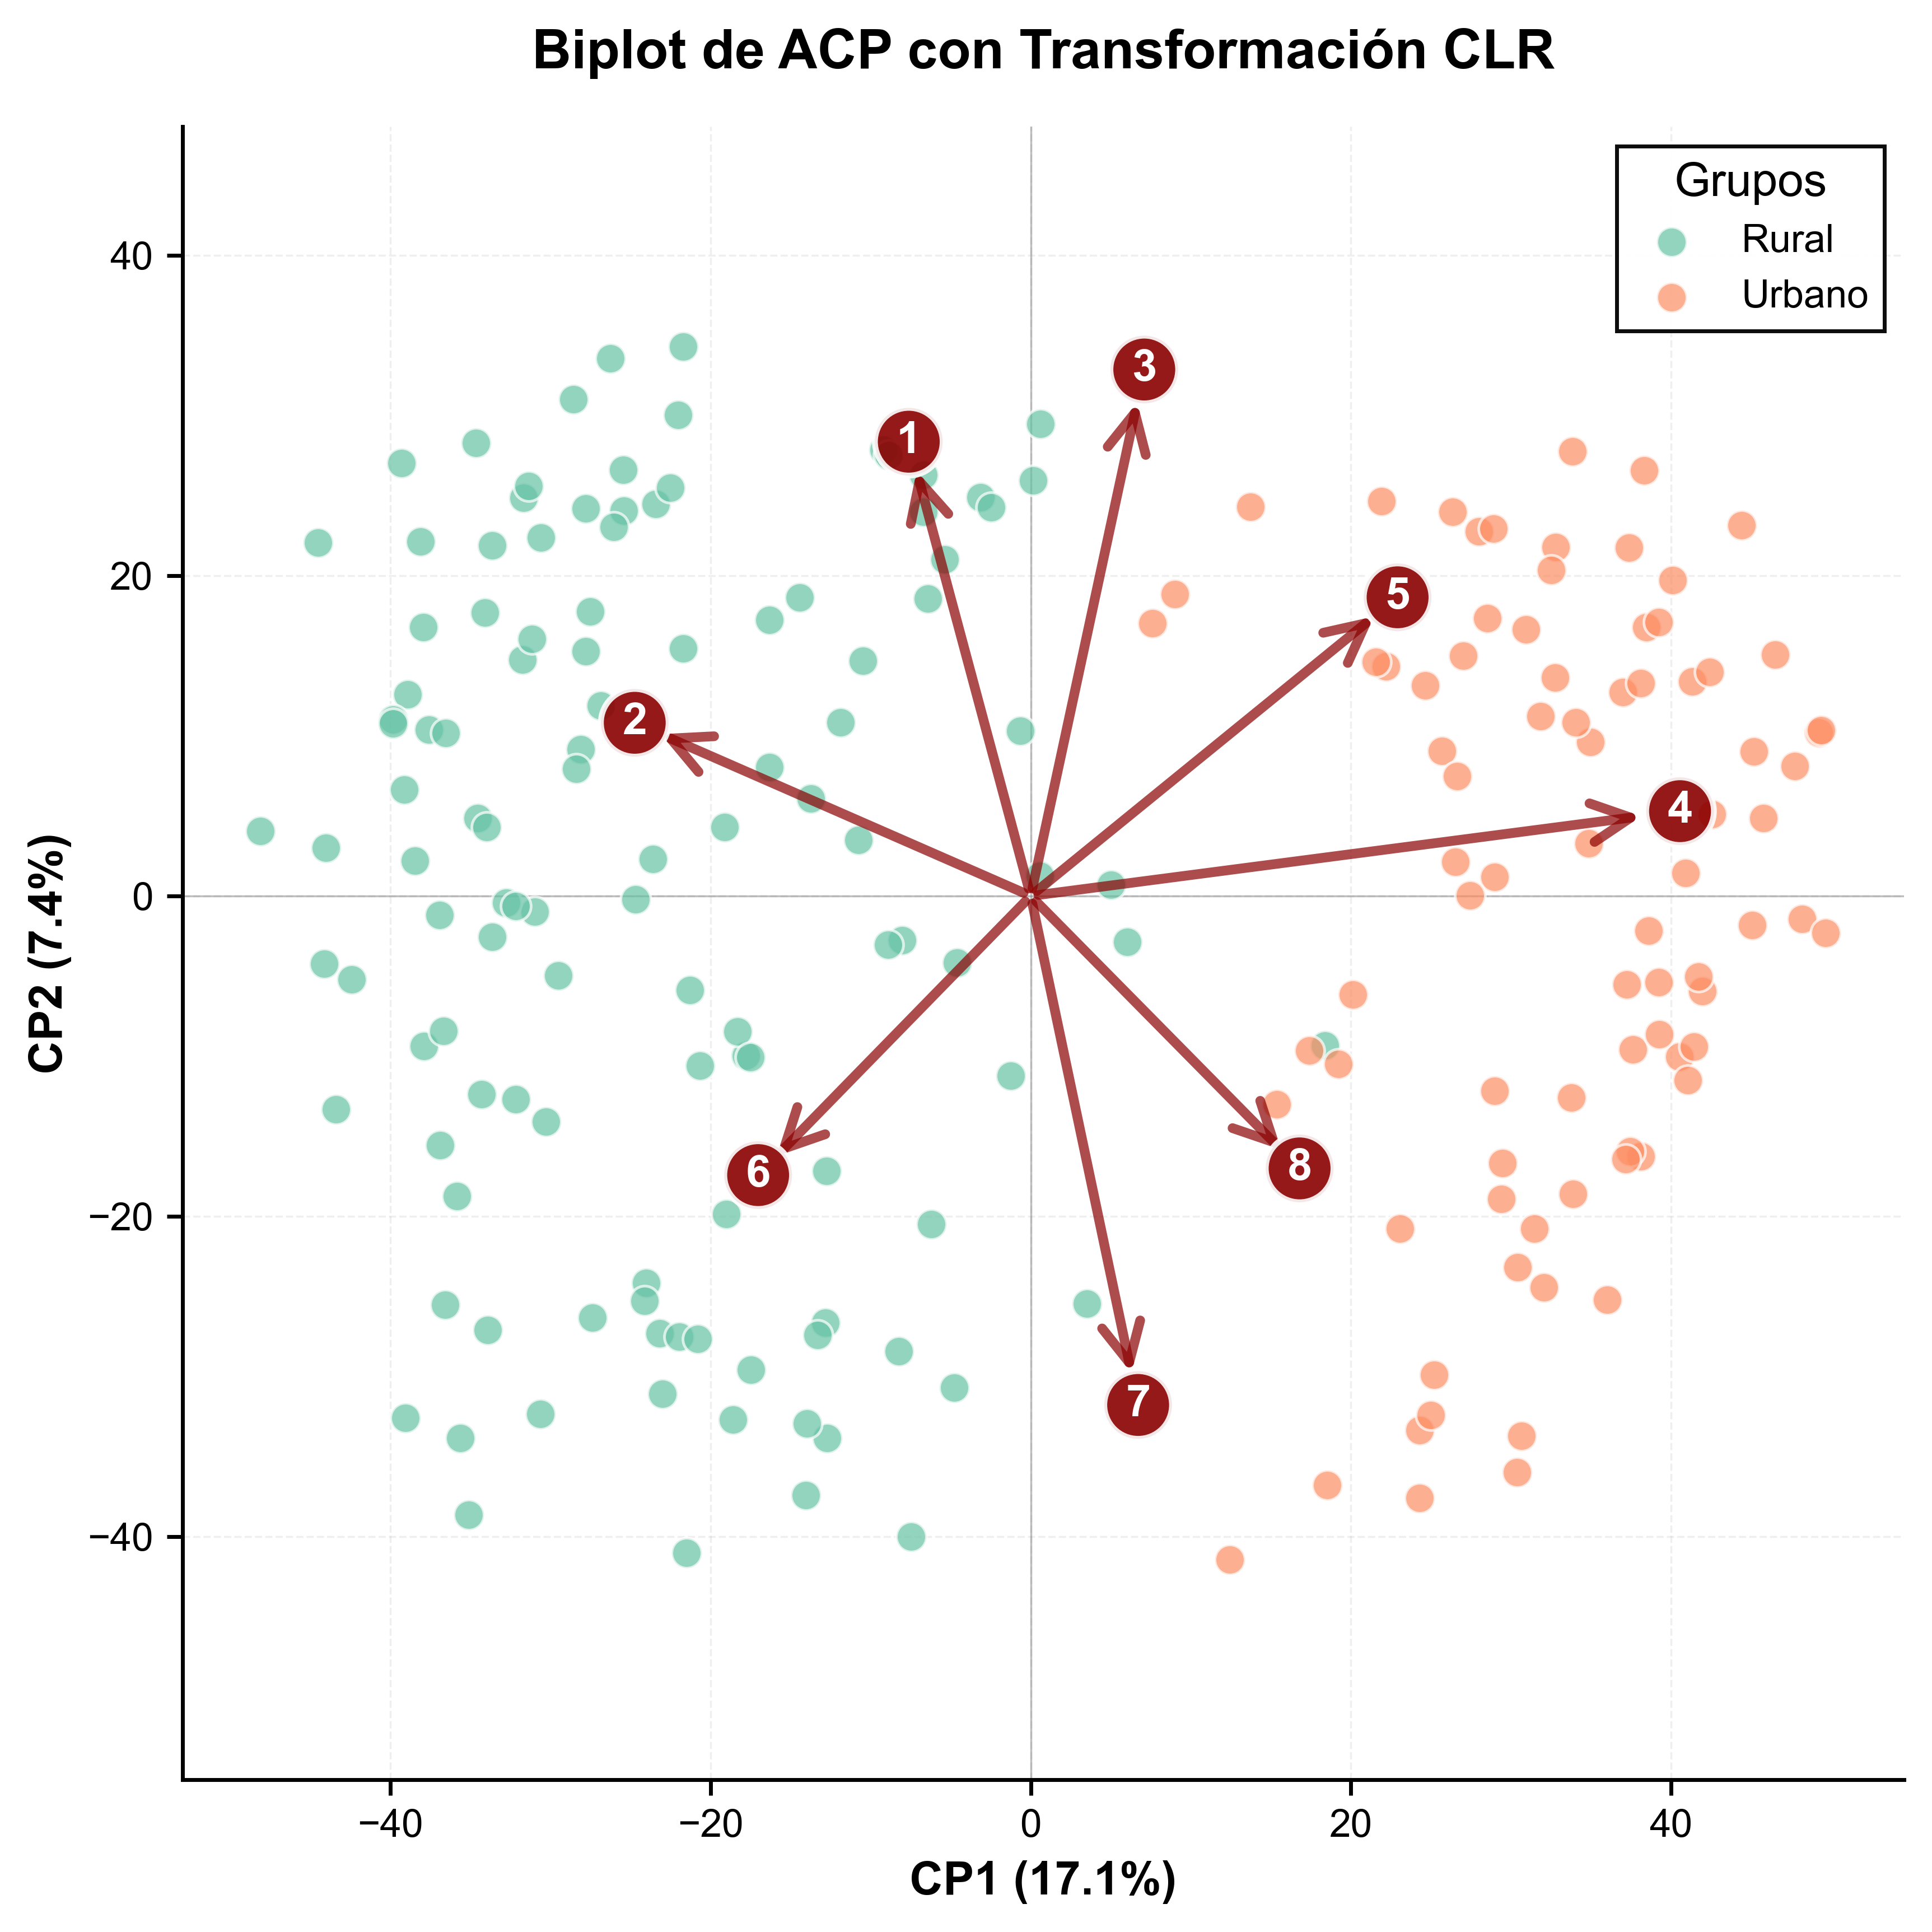


LEYENDA DE DIRECCIONES EN EL BIPLOT
1. Streptococcus, Sarcina, Enterococcus
2. Senegalimassilia, Paratractidigestivibacter, GGB4888 (+2 más)
3. Faecalibacillus, Anaerostipes, Eggerthella
4. Phocaeicola, Bacteroides, Alistipes (+1 más)
5. Thomasclavelia, Ruthenibacterium, Flavonifractor (+2 más)
6. Methanobrevibacter, GGB3306
7. Brotocaccenecus, GGB9708, GGB9747 (+3 más)
8. Dysosmobacter, GGB9699



In [123]:
# Prepare data
X = data_sp.drop(columns=['label']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
# Using absolute values because negative loadings also contribute
contrib = np.sum(np.abs(loadings), axis=1)  # Sum of absolute loadings

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Seleccionadas {len(selected_features)} direcciones distintas de {top_n} características principales")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Dirección {i+1}: {', '.join(feat_group)}")

# Print top contributing genera and their contributions to PCs
print("\n" + "="*80)
print("TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES")
print("="*80)

# Get top 30 genera by total contribution
top_display = 30
top_contrib_idx = np.argsort(contrib)[-top_display:][::-1]

print(f"\n{'Ranking':<8} {'Género':<30} {'Contrib Total':<15} {'CP1':<12} {'CP2':<12}")
print("-"*80)

for rank, idx in enumerate(top_contrib_idx, 1):
    genus_name = feature_names[idx]
    total_contrib = contrib[idx]
    pc1_loading = loadings[idx, 0]
    pc2_loading = loadings[idx, 1]
    
    print(f"{rank:<8} {genus_name:<30} {total_contrib:>12.4f}   {pc1_loading:>10.4f}  {pc2_loading:>10.4f}")

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("- Contrib Total: Contribución euclidiana total a CP1+CP2 (mayor = más importante)")
print("- CP1/CP2: Loadings (correlaciones) con cada componente principal")
print("- Valores positivos: asociación positiva con el componente")
print("- Valores negativos: asociación negativa con el componente")
print("="*80 + "\n")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create SQUARE figure
fig, ax = plt.subplots(figsize=(7, 7), dpi=500)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Diccionario para traducir etiquetas (ajusta según tus datos)
label_translation = {
    'rural': 'Rural',
    'urban': 'Urbano',
    'Rural': 'Rural',
    'Urban': 'Urbano',
    # Añade más traducciones según sea necesario
}

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    # Traducir la etiqueta si existe en el diccionario
    label_es = label_translation.get(group, group)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=label_es,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Calculate scaling factor for arrows
scaling = 200  # Adjust this value as needed

# Initialize texts list for adjustText (if using it)
texts = []

# Create a legend for the arrows
arrow_legend = []

# Draw arrows with numbered labels
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features), 1):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Add numbered label at the end of arrow
    text_offset = 1.05
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   str(i),
                   fontsize=11.5,
                   color='white',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='circle,pad=0.3',
                           facecolor='darkred',
                           edgecolor='white',
                           alpha=0.9,
                           linewidth=1.5),
                   zorder=5)
    texts.append(text)
    
    # Prepare legend entry with prioritized genera
    # Priorizar géneros que NO empiezan con "GGB"
    non_ggb = [g for g in feat_group if not g.startswith('GGB')]
    ggb_genera = [g for g in feat_group if g.startswith('GGB')]
    sorted_feat_group = non_ggb + ggb_genera
    
    # Format the legend entry
    if len(sorted_feat_group) == 1:
        legend_text = f"{i}. {sorted_feat_group[0]}"
    elif len(sorted_feat_group) <= 3:
        legend_text = f"{i}. {', '.join(sorted_feat_group)}"
    else:
        legend_text = f"{i}. {', '.join(sorted_feat_group[:3])} (+{len(sorted_feat_group)-3} más)"
    
    arrow_legend.append(legend_text)

# CRITICAL: Set equal aspect ratio to make plot perfectly square
ax.set_aspect('equal', adjustable='box')

# Get the current axis limits to make them symmetric
x_abs_max = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
y_abs_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
max_lim = max(x_abs_max, y_abs_max)

# Set symmetric limits for both axes (opcional, comentado porque usas axis('equal'))
# ax.set_xlim(-max_lim, max_lim)
# ax.set_ylim(-max_lim, max_lim)

ax.axis('equal')

# Format axes
ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=12, fontweight='bold')
ax.set_title('Biplot de ACP con Transformación CLR', 
             fontsize=14, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=10,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Grupos',
          title_fontsize=12)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print arrow legend after the plot
print("\n" + "="*80)
print("LEYENDA DE DIRECCIONES EN EL BIPLOT")
print("="*80)
for entry in arrow_legend:
    print(entry)
print("="*80 + "\n")

# Optional: Save as high-resolution files for publication
fig.savefig('biplot_amalgamacion_strict_final.png', dpi=500, bbox_inches='tight')